# Analytics - Mapa da Cidadania e Acesso a Informação DF

Notebook exploratório para consumir os 8 arquivos CSV/XLSX da camada RAW e gerar uma primeira leitura analítica sobre LAI, PDAD e projeções populacionais.

Este notebook tem caráter diagnóstico. A camada RAW deve preservar os dados como foram baixados; tratamentos, padronizações e regras de negócio são simulados aqui apenas para orientar a camada Silver.

## 1. Importacoes e Configuracoes

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda valor: f'{valor:,.2f}')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

PERIODO_INICIAL = 2023
PERIODO_FINAL = 2025
CODIGOS_ESPECIAIS_PDAD = {77777, 88888, 99999}

ARQUIVO_REFERENCIA_RAW = 'Participa DF _LAI_ - Pedidos.csv'

def localizar_raw_dir() -> Path:
    cwd = Path.cwd()
    candidatos = [
        cwd,
        cwd / 'Data Layer' / 'raw',
        cwd / 'Data Layer' / '01_raw',
        cwd.parent / 'Data Layer' / 'raw',
        cwd.parent / 'Data Layer' / '01_raw',
        cwd.parent / 'raw',
        cwd.parent / '01_raw',
    ]
    for candidato in candidatos:
        if (candidato / ARQUIVO_REFERENCIA_RAW).exists():
            return candidato
    raise FileNotFoundError(f'Pasta RAW não localizada. Arquivo de referência ausente: {ARQUIVO_REFERENCIA_RAW}')

RAW_DIR = localizar_raw_dir()
RAW_DIR

PosixPath('/home/iggor/Documentos/Mapa-da-Cidadania-e-Acesso-a-Informacao-DF/Data Layer/raw')

## 2. Carregamento dos Dados

### Contexto de negocio

A base combina tres familias de informacao:
- **Participa DF / LAI**: pedidos, recursos, pesquisa de satisfacao e data de atualizacao.
- **PDAD**: moradores, domicilios e dicionario de variaveis.
- **Projecoes populacionais**: populacao por Regiao Administrativa, sexo e faixa etaria entre 2020 e 2030.

O objetivo desta camada analitica e validar cobertura, qualidade e sinais iniciais para alimentar as camadas silver e gold da arquitetura medalhao.

In [3]:
ARQUIVOS = {
    'moradores': 'moradores.csv',
    'domicilios': 'domicilios.xlsx',
    'dicionario': 'dicionario_de_variaveis_pdada_2024_público.xlsx',
    'lai_pedidos': 'Participa DF _LAI_ - Pedidos.csv',
    'lai_recursos': 'Participa DF _LAI_ - Recursos.csv',
    'lai_satisfacao': 'Participa DF _LAI_ - Pesquisa de Satisfação.csv',
    'lai_atualizacao': 'Participa DF _LAI_ - Última Atualização.csv',
    'projecoes_populacionais': 'Dados - Projeções populacionais por Região Administrativa, sexo e faixa etária 2020-2030_1.xlsx',
}

for nome, arquivo in ARQUIVOS.items():
    caminho = RAW_DIR / arquivo
    print(f'{nome:24} {"OK" if caminho.exists() else "NAO ENCONTRADO"} - {caminho.name}')

moradores                OK - moradores.csv
domicilios               OK - domicilios.xlsx
dicionario               OK - dicionario_de_variaveis_pdada_2024_público.xlsx
lai_pedidos              OK - Participa DF _LAI_ - Pedidos.csv
lai_recursos             OK - Participa DF _LAI_ - Recursos.csv
lai_satisfacao           OK - Participa DF _LAI_ - Pesquisa de Satisfação.csv
lai_atualizacao          OK - Participa DF _LAI_ - Última Atualização.csv
projecoes_populacionais  OK - Dados - Projeções populacionais por Região Administrativa, sexo e faixa etária 2020-2030_1.xlsx


In [4]:
def ler_csv_raw(nome_arquivo: str, **kwargs) -> pd.DataFrame:
    caminho = RAW_DIR / nome_arquivo
    tentativas = ['utf-8-sig', 'cp1252', 'latin1']
    ultimo_erro = None
    for encoding in tentativas:
        try:
            return pd.read_csv(caminho, sep=';', encoding=encoding, low_memory=False, **kwargs)
        except UnicodeDecodeError as erro:
            ultimo_erro = erro
    raise ultimo_erro

def ler_excel_raw(nome_arquivo: str, **kwargs):
    return pd.read_excel(RAW_DIR / nome_arquivo, engine='openpyxl', **kwargs)

df_moradores = ler_csv_raw(ARQUIVOS['moradores'])
df_domicilios = ler_excel_raw(ARQUIVOS['domicilios'])
df_lai_pedidos = ler_csv_raw(ARQUIVOS['lai_pedidos'])
df_lai_recursos = ler_csv_raw(ARQUIVOS['lai_recursos'])
df_lai_satisfacao = ler_csv_raw(ARQUIVOS['lai_satisfacao'])
df_lai_atualizacao = ler_csv_raw(ARQUIVOS['lai_atualizacao'])

dict_dicionario = ler_excel_raw(ARQUIVOS['dicionario'], sheet_name=None)
dict_projecoes = ler_excel_raw(ARQUIVOS['projecoes_populacionais'], sheet_name=None)

datasets_tabulares = {
    'moradores': df_moradores,
    'domicilios': df_domicilios,
    'lai_pedidos': df_lai_pedidos,
    'lai_recursos': df_lai_recursos,
    'lai_satisfacao': df_lai_satisfacao,
    'lai_atualizacao': df_lai_atualizacao,
}

datasets_auxiliares = {
    'dicionario_abas': dict_dicionario,
    'projecoes_abas': dict_projecoes,
}

# Mantém compatibilidade com células anteriores do notebook.
datasets = datasets_tabulares

resumo_tabulares = pd.DataFrame([
    {'grupo': 'base_tabular', 'dataset': nome, 'linhas': len(df), 'colunas': df.shape[1]}
    for nome, df in datasets_tabulares.items()
])

resumo_auxiliares = pd.DataFrame([
    {'grupo': 'arquivo_auxiliar', 'dataset': nome, 'linhas': len(valor), 'colunas': np.nan}
    for nome, valor in datasets_auxiliares.items()
])

resumo_carga = pd.concat([resumo_tabulares, resumo_auxiliares], ignore_index=True)
resumo_carga

,dataset,linhas,colunas
0,moradores,69542,134.0
1,domicilios,24845,128.0
2,lai_pedidos,85039,21.0
3,lai_recursos,8455,11.0
4,lai_satisfacao,16167,4.0
5,lai_atualizacao,1,2.0
6,dicionario_abas,13,NaN
7,projecoes_abas,35,NaN


## 3. Qualidade dos Dados

### Insight de negocio

Antes da transformacao para a camada silver, a prioridade e identificar bases com alta incompletude, colunas duplicadas semanticamente e campos de data que precisam de padronizacao. Isso reduz risco de metricas inconsistentes na camada gold.

In [5]:
qualidade = []
for nome, df in datasets.items():
    total_celulas = df.shape[0] * df.shape[1]
    nulos = int(df.isna().sum().sum())
    qualidade.append({
        'dataset': nome,
        'linhas': df.shape[0],
        'colunas': df.shape[1],
        'celulas_nulas': nulos,
        'pct_nulos': round((nulos / total_celulas) * 100, 2) if total_celulas else 0,
        'linhas_duplicadas': int(df.duplicated().sum()),
    })

df_qualidade = pd.DataFrame(qualidade).sort_values('pct_nulos', ascending=False)
df_qualidade

,dataset,linhas,colunas,celulas_nulas,pct_nulos,linhas_duplicadas
3,lai_recursos,8455,11,3020,3.25,1
2,lai_pedidos,85039,21,3072,0.17,0
1,domicilios,24845,128,0,0.00,0
0,moradores,69542,134,0,0.00,0
4,lai_satisfacao,16167,4,0,0.00,0
5,lai_atualizacao,1,2,0,0.00,0


In [6]:
def top_nulos(df: pd.DataFrame, n: int = 15) -> pd.DataFrame:
    nulos = df.isna().sum()
    pct = (nulos / len(df) * 100).round(2)
    return (
        pd.DataFrame({'coluna': nulos.index, 'nulos': nulos.values, 'pct_nulos': pct.values})
        .query('nulos > 0')
        .sort_values('pct_nulos', ascending=False)
        .head(n)
    )

top_nulos(df_lai_pedidos)

,coluna,nulos,pct_nulos
17,RESPOSTAS.DT_RESPOSTA,768,0.9
18,RESPOSTAS.DS_TIPO_RESPOSTA,768,0.9
19,RESPOSTAS.DS_TIPO_CLASSIFICACAO_RESPOSTA,768,0.9
20,RESPOSTAS.DS_CLASSIFICACAO_RESPOSTA,768,0.9


## 4. LAI: Pedidos de Acesso a Informacao

### 4.1 Evolucao temporal dos pedidos

**Insight de negocio:** a evolucao anual indica a demanda social por informacao publica e ajuda a dimensionar capacidade operacional dos orgaos que respondem pedidos de LAI.

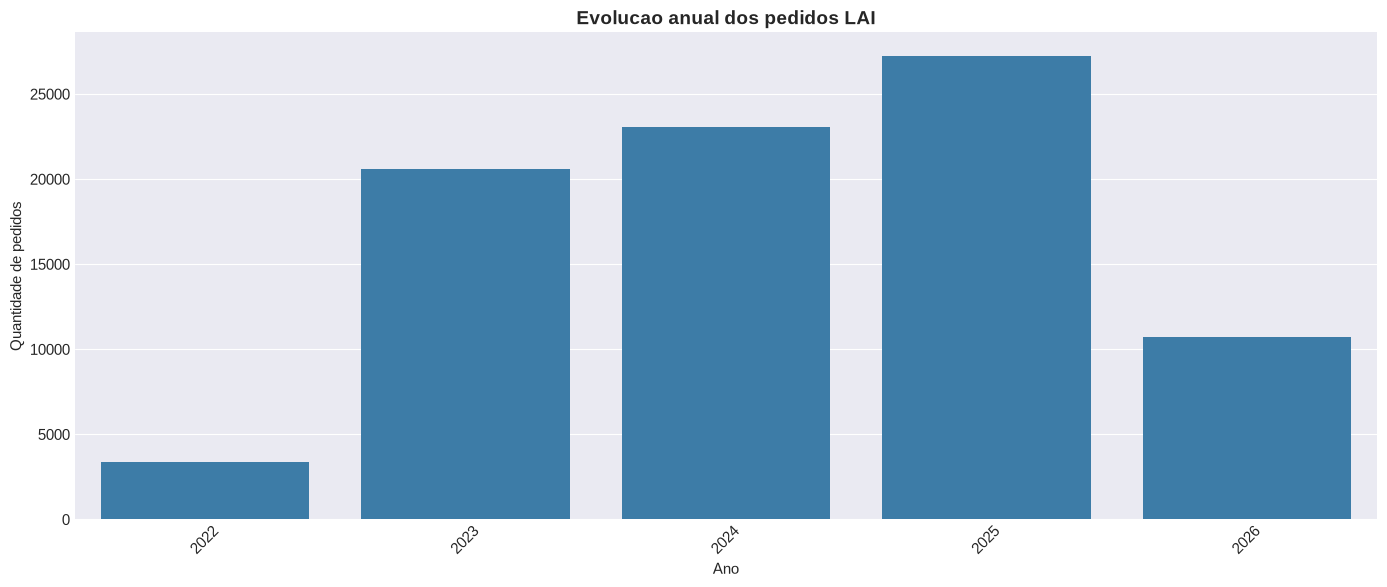

Total de pedidos: 85,039
Ano com mais pedidos: 2025 (27,256)


In [7]:
df_lai_pedidos['DT_PEDIDO_PARSE'] = pd.to_datetime(df_lai_pedidos['DT_PEDIDO'], dayfirst=True, errors='coerce')
df_lai_pedidos['ANO_PEDIDO'] = df_lai_pedidos['DT_PEDIDO_PARSE'].dt.year.fillna(df_lai_pedidos.get('NR_ANO_PEDIDO')).astype('Int64')

pedidos_por_ano = df_lai_pedidos['ANO_PEDIDO'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
ax = sns.barplot(x=pedidos_por_ano.index.astype(str), y=pedidos_por_ano.values, color='#2c7fb8')
ax.set_title('Evolucao anual dos pedidos LAI', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Quantidade de pedidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Total de pedidos: {len(df_lai_pedidos):,}')
print(f'Ano com mais pedidos: {pedidos_por_ano.idxmax()} ({pedidos_por_ano.max():,})')

### 4.1.1 Recorte oficial do projeto: 2023 a 2025

**Decisão analítica:** a RAW permanece completa, mas as análises finais do projeto devem usar cópias filtradas para 2023-2025. Isso evita misturar registros de 2026 da atualização da base com o período institucional definido para Silver/Gold.

In [ ]:
df_lai_pedidos_periodo = df_lai_pedidos[df_lai_pedidos['ANO_PEDIDO'].between(PERIODO_INICIAL, PERIODO_FINAL)].copy()

# Recursos não têm NR_ANO_RECURSO originalmente; a data será criada na seção de recursos.
df_lai_satisfacao['DT_PESQUISA_SATISFACAO_PARSE'] = pd.to_datetime(
    df_lai_satisfacao['DT_PESQUISA_SATISFACAO'], dayfirst=True, errors='coerce'
)
df_lai_satisfacao['ANO_PESQUISA'] = df_lai_satisfacao['DT_PESQUISA_SATISFACAO_PARSE'].dt.year

df_lai_satisfacao_periodo = df_lai_satisfacao[
    df_lai_satisfacao['ANO_PESQUISA'].between(PERIODO_INICIAL, PERIODO_FINAL)
].copy()

resumo_periodo_lai = pd.DataFrame([
    {'dataset': 'lai_pedidos', 'linhas_raw': len(df_lai_pedidos), 'linhas_2023_2025': len(df_lai_pedidos_periodo)},
    {'dataset': 'lai_satisfacao', 'linhas_raw': len(df_lai_satisfacao), 'linhas_2023_2025': len(df_lai_satisfacao_periodo)},
])
resumo_periodo_lai['pct_mantido'] = (resumo_periodo_lai['linhas_2023_2025'] / resumo_periodo_lai['linhas_raw'] * 100).round(2)
resumo_periodo_lai

### 4.2 Situacao, prazo e classificacao das respostas

**Insight de negocio:** situacao e prazo mostram maturidade do processo de atendimento. Classificacoes de resposta ajudam a separar acesso concedido, negativas e casos que exigem tratamento adicional.

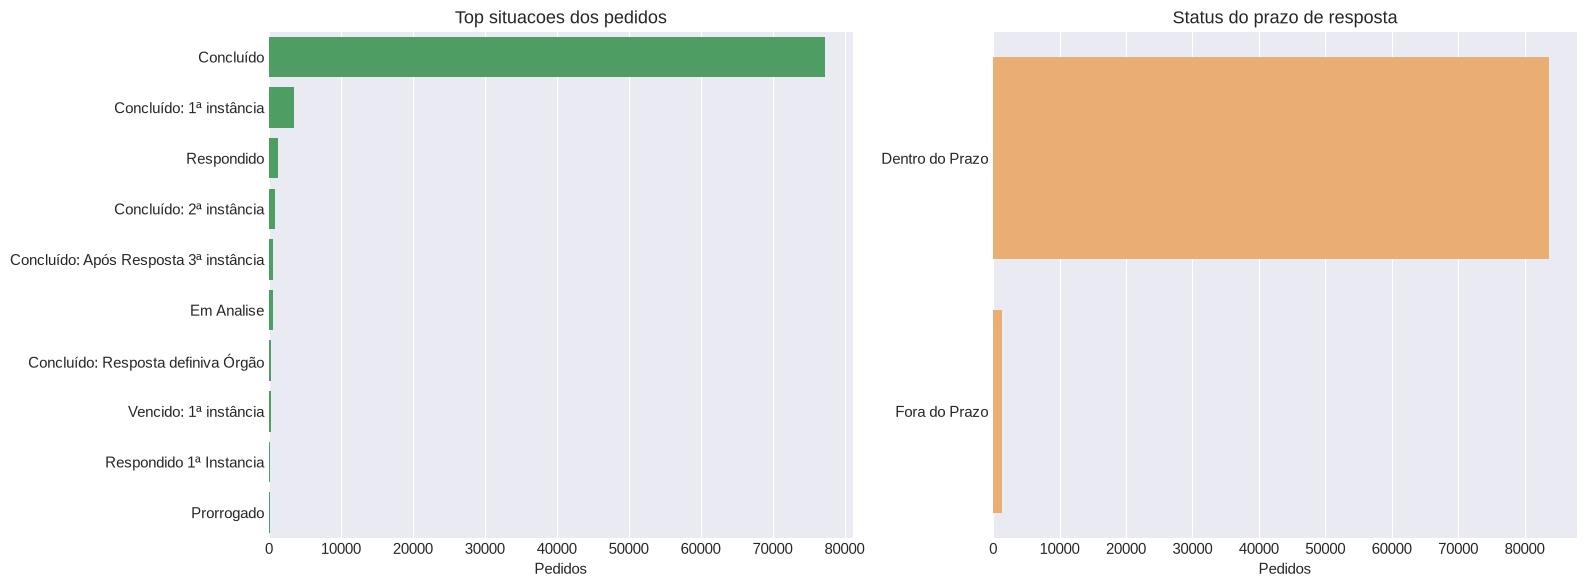

,pedidos
RESPOSTAS.DS_TIPO_CLASSIFICACAO_RESPOSTA,
Acesso Concedido,44103
Outras,15066
A solicitação não é um pedido de informação,14987
Acesso Negado,6811
Acesso Parcialmente Concedido,3273
Nao informado,768
Respostas Para Recursos,31


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

situacao = df_lai_pedidos_periodo['DS_SITUACAO_PEDIDO'].fillna('Não informado').value_counts().head(10)
sns.barplot(y=situacao.index, x=situacao.values, ax=axes[0], color='#41ab5d')
axes[0].set_title('Top situações dos pedidos - 2023 a 2025')
axes[0].set_xlabel('Pedidos')
axes[0].set_ylabel('')

prazo = df_lai_pedidos_periodo['STATUS_PRAZO_RESPOSTA'].fillna('Não informado').value_counts().head(10)
sns.barplot(y=prazo.index, x=prazo.values, ax=axes[1], color='#fdae61')
axes[1].set_title('Status do prazo de resposta - 2023 a 2025')
axes[1].set_xlabel('Pedidos')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

df_lai_pedidos_periodo['pedido_sem_resposta'] = df_lai_pedidos_periodo['RESPOSTAS.DT_RESPOSTA'].isna()

classificacao = (
    df_lai_pedidos_periodo['RESPOSTAS.DS_TIPO_CLASSIFICACAO_RESPOSTA']
    .fillna('Não informado')
    .value_counts()
    .rename_axis('classificacao')
    .reset_index(name='total')
)
classificacao['percentual'] = (classificacao['total'] / classificacao['total'].sum() * 100).round(2)

indicadores_resposta = pd.DataFrame({
    'indicador': ['pedidos_2023_2025', 'pedidos_sem_resposta', 'pct_sem_resposta'],
    'valor': [
        len(df_lai_pedidos_periodo),
        int(df_lai_pedidos_periodo['pedido_sem_resposta'].sum()),
        round(df_lai_pedidos_periodo['pedido_sem_resposta'].mean() * 100, 2),
    ]
})

display(indicadores_resposta)
classificacao

### 4.3 Orgaos mais demandados

**Insight de negocio:** orgaos com maior volume de pedidos tendem a concentrar temas de maior interesse publico e devem ser priorizados em paineis de transparencia ativa.

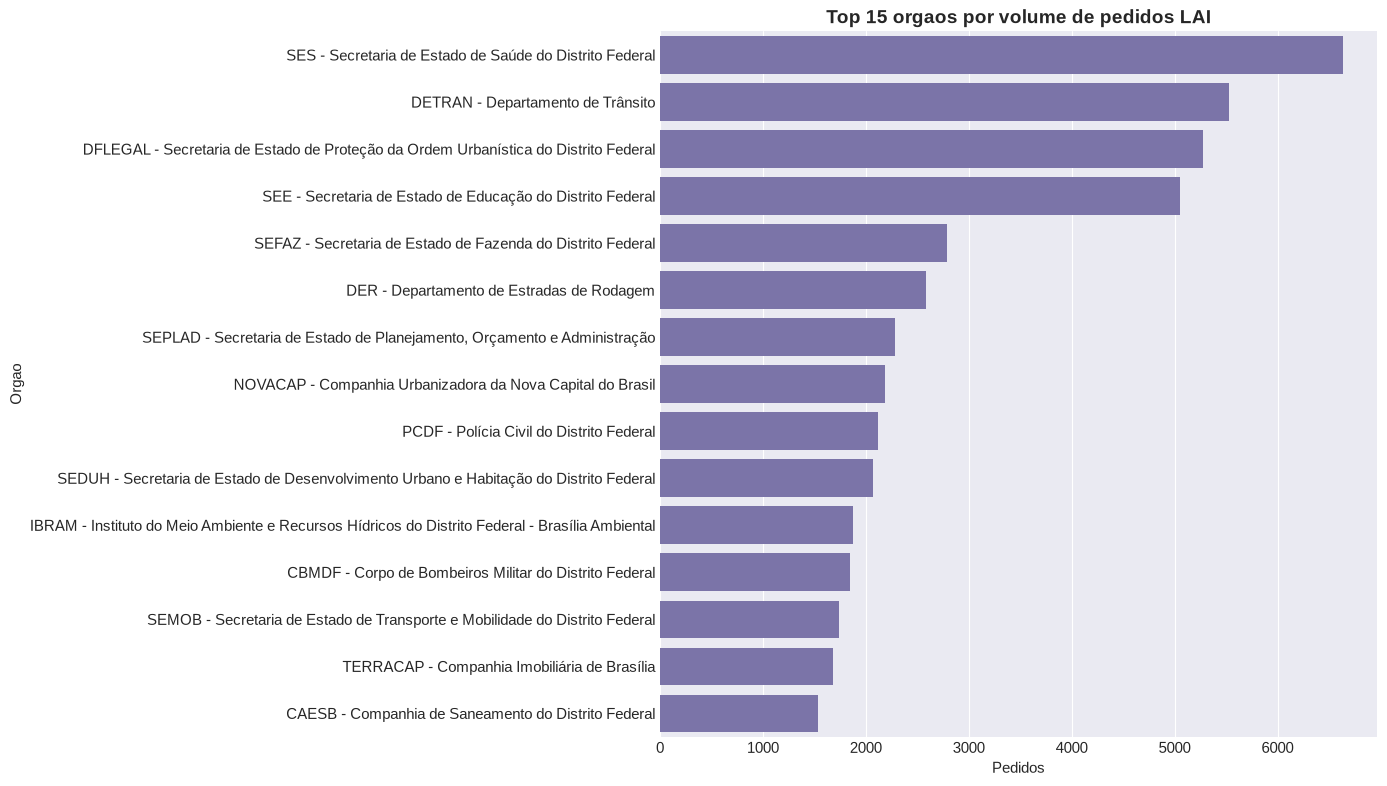

,pedidos
DS_UNIDADE,
SES - Secretaria de Estado de Saúde do Distrito Federal,6635
DETRAN - Departamento de Trânsito,5527
DFLEGAL - Secretaria de Estado de Proteção da Ordem Urbanística do Distrito Federal,5272
SEE - Secretaria de Estado de Educação do Distrito Federal,5051
SEFAZ - Secretaria de Estado de Fazenda do Distrito Federal,2793
DER - Departamento de Estradas de Rodagem,2583
"SEPLAD - Secretaria de Estado de Planejamento, Orçamento e Administração",2280
NOVACAP - Companhia Urbanizadora da Nova Capital do Brasil,2190
PCDF - Polícia Civil do Distrito Federal,2117


In [9]:
orgaos = df_lai_pedidos_periodo['DS_UNIDADE'].fillna('Não informado').value_counts().head(15)

plt.figure(figsize=(14, 8))
sns.barplot(y=orgaos.index, x=orgaos.values, color='#756bb1')
plt.title('Top 15 órgãos por volume de pedidos LAI - 2023 a 2025', fontsize=14, fontweight='bold')
plt.xlabel('Pedidos')
plt.ylabel('Órgão')
plt.tight_layout()
plt.show()

orgaos.to_frame('pedidos')

### 4.4 Recorte institucional: DPDF

**Insight de negócio:** a análise específica da Defensoria Pública do Distrito Federal conecta a base de LAI ao foco institucional do projeto. Mesmo quando o volume for baixo, o recorte permite medir demanda, classificação das respostas, prazo e pedidos sem resposta.

In [ ]:
padrao_dpdf = 'DEFENSORIA|DPDF|DEFENSORIA PÚBLICA|DEFENSORIA PUBLICA'
mask_dpdf = df_lai_pedidos_periodo['DS_UNIDADE'].str.contains(padrao_dpdf, case=False, na=False, regex=True)
df_lai_dpdf = df_lai_pedidos_periodo[mask_dpdf].copy()

if df_lai_dpdf.empty:
    print('Nenhum pedido associado à DPDF foi localizado no recorte 2023-2025 usando o padrão:', padrao_dpdf)
else:
    dpdf_ano = df_lai_dpdf['ANO_PEDIDO'].value_counts().sort_index()
    dpdf_classificacao = (
        df_lai_dpdf['RESPOSTAS.DS_TIPO_CLASSIFICACAO_RESPOSTA']
        .fillna('Não informado')
        .value_counts()
        .rename_axis('classificacao')
        .reset_index(name='total')
    )
    dpdf_classificacao['percentual'] = (dpdf_classificacao['total'] / dpdf_classificacao['total'].sum() * 100).round(2)

    df_lai_dpdf['DT_RESPOSTA_PARSE'] = pd.to_datetime(df_lai_dpdf['RESPOSTAS.DT_RESPOSTA'], dayfirst=True, errors='coerce')
    df_lai_dpdf['dias_resposta'] = (df_lai_dpdf['DT_RESPOSTA_PARSE'] - df_lai_dpdf['DT_PEDIDO_PARSE']).dt.days

    resumo_dpdf = pd.DataFrame({
        'indicador': ['pedidos_dpdf', 'pedidos_sem_resposta', 'pct_sem_resposta', 'tempo_medio_resposta_dias'],
        'valor': [
            len(df_lai_dpdf),
            int(df_lai_dpdf['pedido_sem_resposta'].sum()),
            round(df_lai_dpdf['pedido_sem_resposta'].mean() * 100, 2),
            round(df_lai_dpdf['dias_resposta'].dropna().mean(), 2),
        ]
    })

    display(resumo_dpdf)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=dpdf_ano.index.astype(str), y=dpdf_ano.values, color='#2c7fb8')
    plt.title('Pedidos LAI associados à DPDF por ano')
    plt.xlabel('Ano')
    plt.ylabel('Pedidos')
    plt.tight_layout()
    plt.show()

    display(dpdf_classificacao)
    display(df_lai_dpdf[['NR_PEDIDO_PARTICIPA', 'ANO_PEDIDO', 'DS_UNIDADE', 'DS_SITUACAO_PEDIDO', 'STATUS_PRAZO_RESPOSTA', 'RESPOSTAS.DS_TIPO_CLASSIFICACAO_RESPOSTA']].head(20))

## 5. LAI: Recursos e Pesquisa de Satisfacao

### Insight de negocio

Recursos indicam friccao no atendimento original. Satisfacao mostra a percepcao do usuario e pode orientar melhorias de linguagem, completude e tempestividade das respostas.

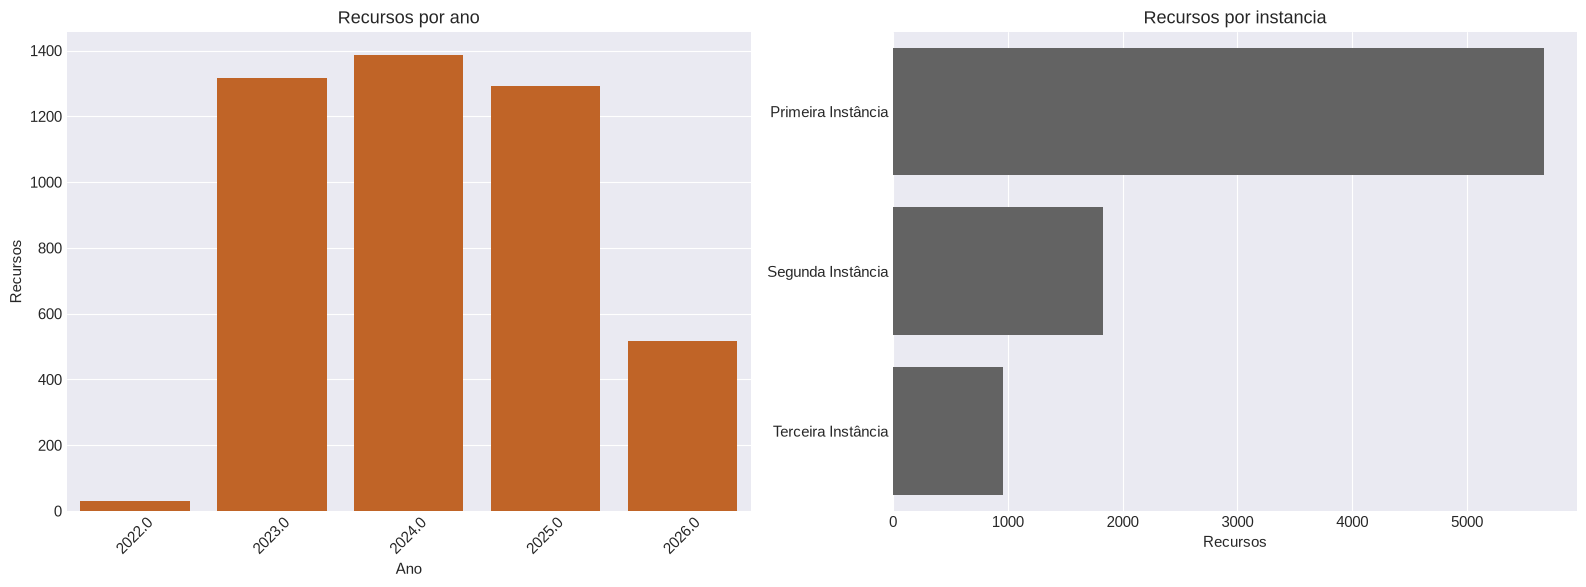

Total de recursos: 8,455
Pedidos com recurso: 5,674


In [10]:
df_lai_recursos['DT_RECURSO_PARSE'] = pd.to_datetime(df_lai_recursos['DT_RECURSO'], dayfirst=True, errors='coerce')
df_lai_recursos['ANO_RECURSO'] = df_lai_recursos['DT_RECURSO_PARSE'].dt.year

df_lai_recursos_periodo = df_lai_recursos[
    df_lai_recursos['ANO_RECURSO'].between(PERIODO_INICIAL, PERIODO_FINAL)
].copy()

recursos_por_ano = df_lai_recursos_periodo['ANO_RECURSO'].value_counts().sort_index()
instancias = df_lai_recursos_periodo['DS_INSTANCIA'].fillna('Não informado').value_counts()

taxa_recurso = (
    df_lai_recursos_periodo['NR_PEDIDO_PARTICIPA'].nunique()
    / df_lai_pedidos_periodo['NR_PEDIDO_PARTICIPA'].nunique()
    * 100
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=recursos_por_ano.index.astype(str), y=recursos_por_ano.values, ax=axes[0], color='#d95f0e')
axes[0].set_title('Recursos por ano - 2023 a 2025')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Recursos')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(y=instancias.index, x=instancias.values, ax=axes[1], color='#636363')
axes[1].set_title('Recursos por instância - 2023 a 2025')
axes[1].set_xlabel('Recursos')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

pd.DataFrame({
    'indicador': ['total_recursos', 'pedidos_com_recurso', 'taxa_recurso_pct'],
    'valor': [
        len(df_lai_recursos_periodo),
        df_lai_recursos_periodo['NR_PEDIDO_PARTICIPA'].nunique(),
        round(taxa_recurso, 2),
    ]
})

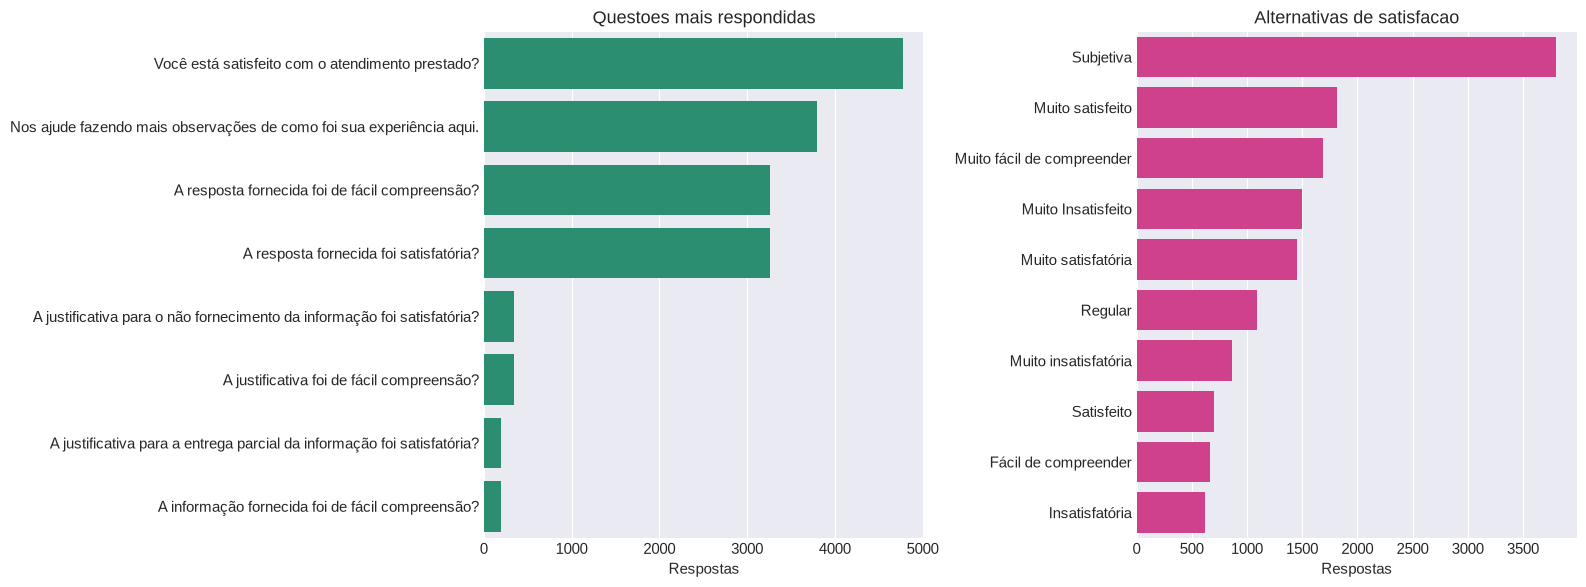

,DT_ULTIMA_ATUALIZACAO,DT_ULTIMA_ATUALIZACAO_COMPLETA
0,04/05/2026,04/05/2026 16:13


In [11]:
questoes = df_lai_satisfacao_periodo['DS_QUESTAO'].fillna('Não informado').value_counts().head(10)
alternativas = df_lai_satisfacao_periodo['DS_ALTERNATIVA'].fillna('Não informado').value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(y=questoes.index, x=questoes.values, ax=axes[0], color='#1b9e77')
axes[0].set_title('Questões mais respondidas - 2023 a 2025')
axes[0].set_xlabel('Respostas')
axes[0].set_ylabel('')

sns.barplot(y=alternativas.index, x=alternativas.values, ax=axes[1], color='#e7298a')
axes[1].set_title('Alternativas de satisfação - 2023 a 2025')
axes[1].set_xlabel('Respostas')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print('Última atualização informada pela fonte RAW:')
df_lai_atualizacao

## 6. PDAD: Moradores e Domicilios

### Insight de negocio

A PDAD sustenta o perfil socioeconomico por Regiao Administrativa. Nesta etapa exploratoria, o foco e conferir cobertura, pesos amostrais e variaveis de renda, idade, escolaridade e domicilio para orientar a modelagem silver.

In [12]:
colunas_chave_moradores = [c for c in ['localidade', 'idade_calculada', 'renda_ind', 'renda_ind_r', 'escolaridade', 'peso_mor'] if c in df_moradores.columns]
colunas_chave_domicilios = [c for c in ['localidade', 'renda_dom', 'renda_dom_r', 'peso_dom'] if c in df_domicilios.columns]

print('Colunas-chave moradores:', colunas_chave_moradores)
print('Colunas-chave domicilios:', colunas_chave_domicilios)

display(df_moradores[colunas_chave_moradores].head())
display(df_domicilios[colunas_chave_domicilios].head() if colunas_chave_domicilios else df_domicilios.head())

Colunas-chave moradores: ['localidade', 'idade_calculada', 'renda_ind', 'renda_ind_r', 'escolaridade', 'peso_mor']
Colunas-chave domicilios: ['localidade', 'peso_dom']


,localidade,idade_calculada,renda_ind,renda_ind_r,escolaridade,peso_mor
0,5330,49,0,0,5,"78,62021308"
1,5320,35,99999,99999,7,"148,8188948"
2,5320,41,99999,99999,7,"212,8951827"
3,5320,5,0,0,1,"341,5004303"
4,5320,3,0,0,1,"244,9026476"


,localidade,peso_dom
0,5330,83.862804
1,5320,164.857889
2,5315,88.059672
3,5326,53.458442
4,5314,31.392469


### 6.1 Códigos especiais e pesos amostrais

**Ponto crítico:** a PDAD pode usar códigos sentinela, como `99999`, `88888` e `77777`, para respostas ausentes, não aplicáveis ou categorias especiais. Na RAW eles devem ser apenas identificados; na Silver precisam ser tratados antes de qualquer média, proporção ou índice.

In [ ]:
def numero_ptbr(serie: pd.Series) -> pd.Series:
    return pd.to_numeric(serie.astype(str).str.replace(',', '.', regex=False), errors='coerce')

def diagnosticar_codigos_especiais(df: pd.DataFrame, colunas: list[str]) -> pd.DataFrame:
    registros = []
    for coluna in colunas:
        if coluna not in df.columns:
            continue
        valores = numero_ptbr(df[coluna])
        total = len(valores)
        for codigo in sorted(CODIGOS_ESPECIAIS_PDAD):
            qtd = int((valores == codigo).sum())
            if qtd:
                registros.append({
                    'coluna': coluna,
                    'codigo_especial': codigo,
                    'ocorrencias': qtd,
                    'percentual': round(qtd / total * 100, 2),
                })
    colunas_saida = ['coluna', 'codigo_especial', 'ocorrencias', 'percentual']
    if not registros:
        return pd.DataFrame(columns=colunas_saida)
    return pd.DataFrame(registros, columns=colunas_saida).sort_values(['coluna', 'codigo_especial'])

colunas_diagnostico_pdad = [
    'idade_calculada', 'renda_ind', 'renda_ind_r', 'escolaridade', 'peso_mor',
    'renda_dom', 'renda_dom_r', 'peso_dom', 'A01npessoas'
]

diagnostico_codigos_moradores = diagnosticar_codigos_especiais(df_moradores, colunas_diagnostico_pdad)
diagnostico_codigos_domicilios = diagnosticar_codigos_especiais(df_domicilios, colunas_diagnostico_pdad)

if 'peso_mor' in df_moradores.columns:
    df_moradores['peso_mor_num'] = numero_ptbr(df_moradores['peso_mor'])
if 'peso_dom' in df_domicilios.columns:
    df_domicilios['peso_dom_num'] = numero_ptbr(df_domicilios['peso_dom'])

display(diagnostico_codigos_moradores)
display(diagnostico_codigos_domicilios)

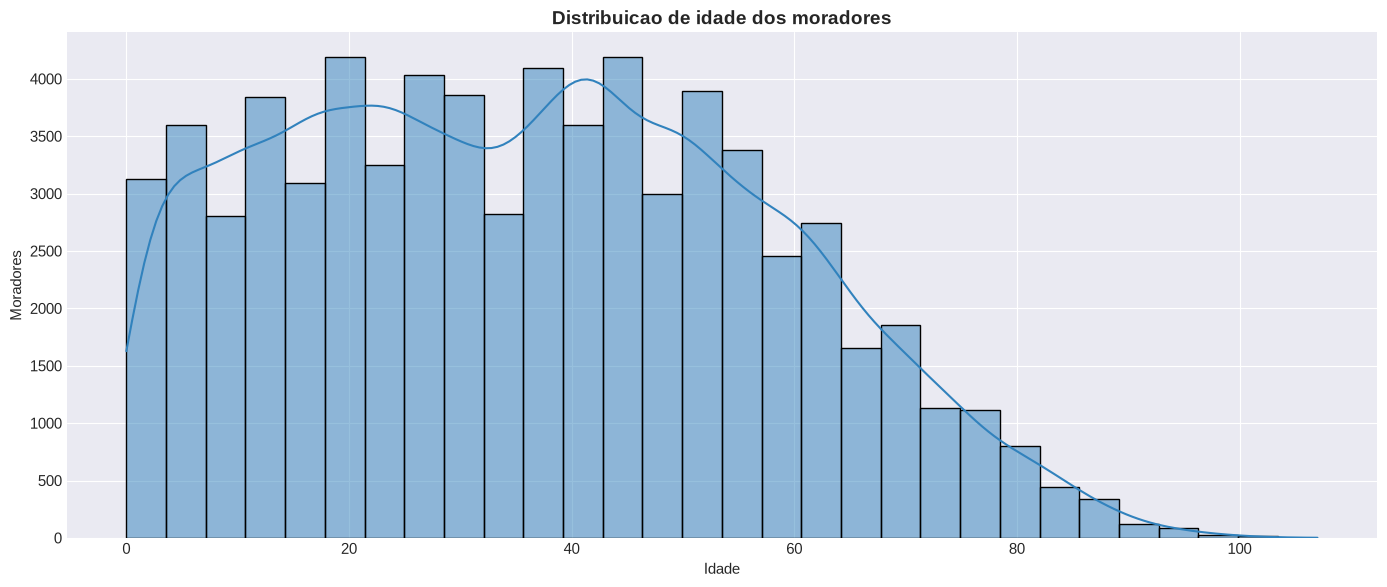

Idade media: 36.2
Idade mediana: 36.0


In [13]:
if 'idade_calculada' in df_moradores.columns:
    idade = numero_ptbr(df_moradores['idade_calculada'])
    idade_valida = idade[(idade >= 0) & (idade <= 120)]

    plt.figure(figsize=(14, 6))
    sns.histplot(idade_valida, bins=30, kde=True, color='#3182bd')
    plt.title('Distribuição de idade dos moradores', fontsize=14, fontweight='bold')
    plt.xlabel('Idade')
    plt.ylabel('Moradores')
    plt.tight_layout()
    plt.show()

    resumo_idade = {
        'idade_media_simples': round(idade_valida.mean(), 2),
        'idade_mediana': round(idade_valida.median(), 2),
    }

    if 'peso_mor_num' in df_moradores.columns:
        base_idade_peso = pd.DataFrame({'idade': idade, 'peso': df_moradores['peso_mor_num']}).dropna()
        base_idade_peso = base_idade_peso[(base_idade_peso['idade'].between(0, 120)) & (base_idade_peso['peso'] > 0)]
        resumo_idade['idade_media_ponderada'] = round(np.average(base_idade_peso['idade'], weights=base_idade_peso['peso']), 2)

    pd.DataFrame([resumo_idade])

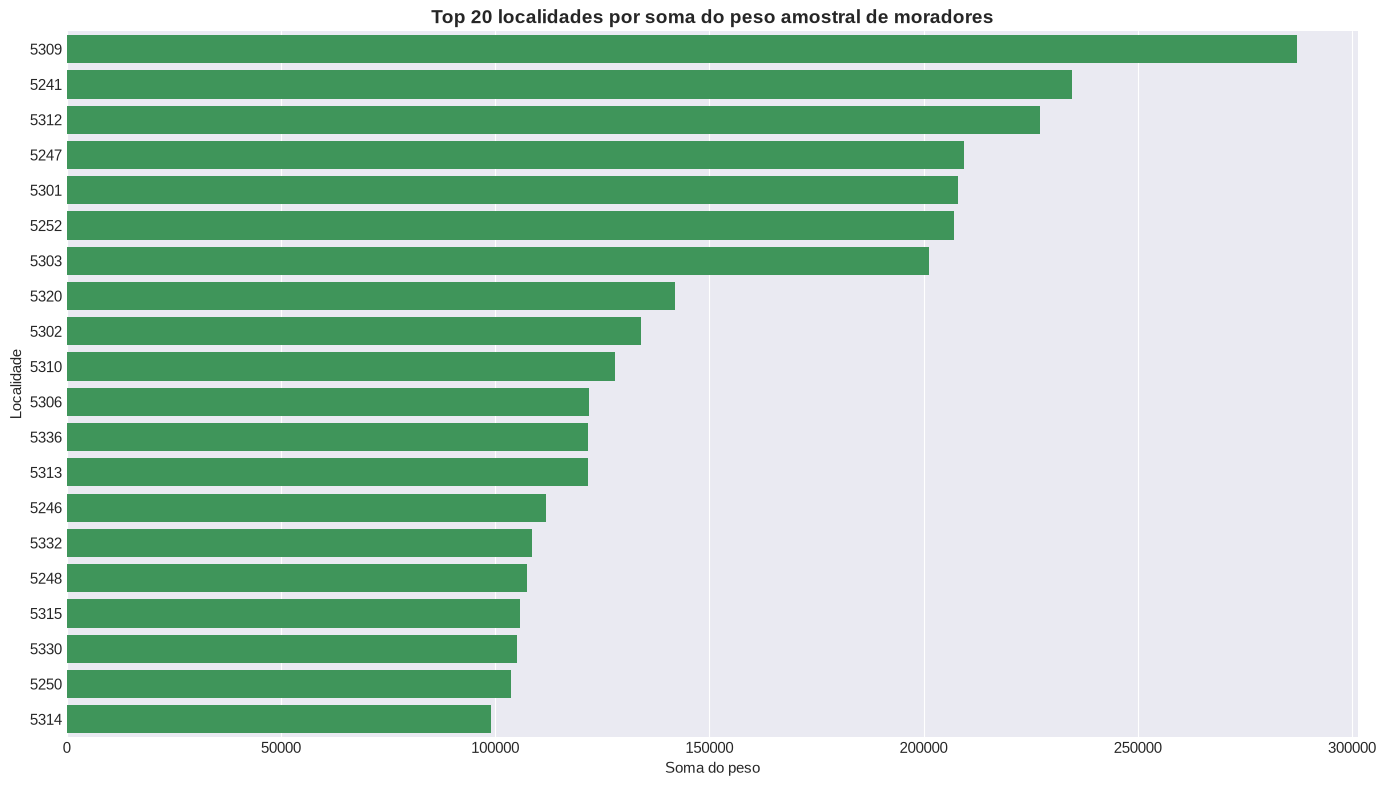

In [14]:
if {'localidade', 'peso_mor_num'}.issubset(df_moradores.columns):
    moradores_por_ra = (
        df_moradores.groupby('localidade', dropna=False)['peso_mor_num']
        .sum()
        .sort_values(ascending=False)
        .head(20)
    )

    plt.figure(figsize=(14, 8))
    sns.barplot(y=moradores_por_ra.index.astype(str), x=moradores_por_ra.values, color='#31a354')
    plt.title('Top 20 localidades por soma do peso amostral de moradores', fontsize=14, fontweight='bold')
    plt.xlabel('Soma do peso')
    plt.ylabel('Localidade')
    plt.tight_layout()
    plt.show()

    display(moradores_por_ra.to_frame('peso_moradores'))

if {'renda_ind', 'peso_mor_num'}.issubset(df_moradores.columns):
    renda = numero_ptbr(df_moradores['renda_ind'])
    base_renda = pd.DataFrame({
        'localidade': df_moradores.get('localidade'),
        'renda': renda,
        'peso': df_moradores['peso_mor_num'],
    })
    base_renda = base_renda[
        (~base_renda['renda'].isin(CODIGOS_ESPECIAIS_PDAD))
        & (base_renda['renda'] >= 0)
        & (base_renda['peso'] > 0)
    ].dropna(subset=['renda', 'peso'])

    renda_ponderada = np.average(base_renda['renda'], weights=base_renda['peso']) if not base_renda.empty else np.nan
    print(f'Renda individual média ponderada, excluindo códigos especiais: R$ {renda_ponderada:,.2f}')

## 7. Projecoes Populacionais

### Insight de negocio

As projecoes populacionais permitem normalizar indicadores por porte populacional e comparar regioes de tamanhos diferentes. Isso e essencial para criar indicadores como pedidos LAI por 10 mil habitantes.

In [15]:
abas_projecoes = pd.DataFrame({
    'aba': list(dict_projecoes.keys()),
    'linhas': [len(df) for df in dict_projecoes.values()],
    'colunas': [df.shape[1] for df in dict_projecoes.values()],
})
abas_projecoes

,aba,linhas,colunas
0,DF,42,34
1,RA's,37,12
2,Águas Claras,42,34
3,Arniqueira,42,34
4,Brazlândia,42,34
5,Candangolândia,42,34
6,Ceilândia,42,34
7,Cruzeiro,42,34
8,Fercal,42,34
9,Gama,42,34


In [16]:
def transformar_populacao_ra_ano(nome_arquivo: str, periodo=range(PERIODO_INICIAL, PERIODO_FINAL + 1)) -> pd.DataFrame:
    bruto = pd.read_excel(RAW_DIR / nome_arquivo, sheet_name="RA's", header=None, engine='openpyxl')
    anos = [int(a) for a in bruto.iloc[3, 1:].dropna().tolist()]
    dados = bruto.iloc[4:, :len(anos) + 1].copy()
    dados.columns = ['regiao_administrativa'] + anos
    dados = dados.dropna(subset=['regiao_administrativa'])
    longo = dados.melt(
        id_vars='regiao_administrativa',
        value_vars=[ano for ano in anos if ano in periodo],
        var_name='ano',
        value_name='populacao',
    )
    longo['ano'] = longo['ano'].astype(int)
    longo['populacao'] = pd.to_numeric(longo['populacao'], errors='coerce')
    return longo.dropna(subset=['populacao']).reset_index(drop=True)

def transformar_populacao_sexo_idade(nome_arquivo: str, periodo=range(PERIODO_INICIAL, PERIODO_FINAL + 1)) -> pd.DataFrame:
    abas = pd.read_excel(RAW_DIR / nome_arquivo, sheet_name=None, header=None, engine='openpyxl')
    registros = []
    for regiao, bruto in abas.items():
        if regiao == "RA's" or bruto.shape[0] < 6:
            continue

        ano_atual = None
        mapa_colunas = []
        for col in range(1, bruto.shape[1]):
            valor_ano = bruto.iloc[3, col]
            if pd.notna(valor_ano):
                try:
                    ano_atual = int(valor_ano)
                except (TypeError, ValueError):
                    ano_atual = None
            sexo = bruto.iloc[4, col]
            if ano_atual in periodo and pd.notna(sexo):
                mapa_colunas.append((col, ano_atual, str(sexo).strip().lower()))

        for linha in range(5, bruto.shape[0]):
            idade = bruto.iloc[linha, 0]
            if pd.isna(idade):
                continue
            for col, ano, sexo in mapa_colunas:
                populacao = pd.to_numeric(bruto.iloc[linha, col], errors='coerce')
                if pd.notna(populacao):
                    registros.append({
                        'regiao_administrativa': regiao,
                        'idade': idade,
                        'ano': ano,
                        'sexo': sexo,
                        'populacao': populacao,
                    })

    return pd.DataFrame(registros)

df_populacao_ra_ano = transformar_populacao_ra_ano(ARQUIVOS['projecoes_populacionais'])
df_populacao_sexo_idade = transformar_populacao_sexo_idade(ARQUIVOS['projecoes_populacionais'])

pop_total_ano = df_populacao_ra_ano.groupby('ano')['populacao'].sum()
plt.figure(figsize=(12, 6))
sns.lineplot(x=pop_total_ano.index.astype(str), y=pop_total_ano.values, marker='o', color='#08519c')
plt.title('Projeção populacional agregada das RAs - 2023 a 2025', fontsize=14, fontweight='bold')
plt.xlabel('Ano')
plt.ylabel('População projetada')
plt.tight_layout()
plt.show()

print('Formato longo RA/ano:', df_populacao_ra_ano.shape)
print('Formato longo sexo/idade:', df_populacao_sexo_idade.shape)
display(df_populacao_ra_ano.head())
display(df_populacao_sexo_idade.head())

Colunas de ano identificadas: []


,DISTRITO FEDERAL,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,SÃO SEBASTIÃO,SCIA,SIA,SOBRADINHO,SOBRADINHO II,SOL NASCENTE/ PÔR DO SOL,SUDOESTE/OCTOGONAL,TAGUATINGA,VARJÃO,VICENTE PIRES
0,"População por sexo e idade, em 1º de julho - 2...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Idade,2020,NaN,NaN,2021,NaN,NaN,2022,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Total,Homens,Mulheres,Total,Homens,Mulheres,Total,Homens,Mulheres,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,43257,22149.0,21108,43110,22074,21036.0,42922.0,21978.0,20944,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8. Dicionario de Dados

### Insight de negocio

O dicionario deve ser usado como contrato semantico da camada silver. Ele ajuda a traduzir codigos da PDAD para categorias legiveis e reduz ambiguidade na criacao de dimensoes e fatos.

In [17]:
abas_dicionario = pd.DataFrame({
    'aba': list(dict_dicionario.keys()),
    'linhas': [len(df) for df in dict_dicionario.values()],
    'colunas': [df.shape[1] for df in dict_dicionario.values()],
})
abas_dicionario

,aba,linhas,colunas
0,domicilios,374,4
1,moradores,580,4
2,anexo_1,48,3
3,anexo_2,58,3
4,anexo_3,58,3
5,anexo_4,277,5
6,anexo_5,5572,3
7,anexo_6,278,3
8,anexo_7,5654,8
9,anexo_8,54,3


In [18]:
for aba in ['moradores', 'domicilios']:
    if aba in dict_dicionario:
        print(f'\n=== {aba} ===')
        display(dict_dicionario[aba].head(10))


=== moradores ===


,Coluna,Descrição da coluna,Valor,Descrição do valor
0,A01nficha,Número da ficha,-,-
1,A01uf,Unidade da Federação,52,Goiás
2,NaN,NaN,53,Distrito Federal
3,localidade,Região Administrativa (DF) ou Município da amo...,-,-
4,setor_distrito,Setor da Região Administrativa (DF) ou Distrit...,-,Anexo 2
5,morador_id,Identificação única do morador,-,-
6,index,Identificação do morador no domicílio,-,-
7,idade_calculada,Idade calculada,-,-
8,E02_1,Data de Nascimento (dd/mm/yyyy),-,-
9,E02_2,Data de Nascimento (mm/yyyy),-,-



=== domicilios ===


,Coluna,Descrição da coluna,Valor,Descrição do valor
0,starttime,Data e hora da visita,-,-
1,A01nficha,Número da ficha,-,-
2,A01uf,Unidade da Federação,52,Goiás
3,NaN,NaN,53,Distrito Federal
4,localidade,Região Administrativa (DF) ou Município da amo...,-,Ver Anexo 1
5,setor_distrito,Setor da Região Administrativa (DF) ou Distrit...,-,Ver Anexo 2
6,A01ncriancas,Número de moradores do domicílio com idade ent...,-,-
7,A01npessoas13,Número de moradores do domicílio com 13 anos o...,-,-
8,A01npessoas,Qtd. de pessoas no domicílio,-,-
9,B01,Espécie do domicílio,1,Permanente


## 9. Sinais para a Camada Silver e Gold

### Recomendações técnicas

1. Manter a RAW imutável e aplicar regras de negócio apenas em Silver.
2. Filtrar LAI para o recorte oficial de 2023 a 2025.
3. Padronizar nomes de colunas em `snake_case` na camada Silver.
4. Converter datas LAI para `datetime` e derivar ano, mês, tempo de resposta e flag `pedido_sem_resposta`.
5. Criar métricas percentuais de classificação de resposta, não apenas contagens absolutas.
6. Incluir recorte institucional da DPDF nas métricas finais.
7. Tratar códigos sentinela da PDAD, como `99999`, `88888` e `77777`, antes de cálculos.
8. Converter pesos amostrais da PDAD para número e usar médias/proporções ponderadas.
9. Usar o dicionário da PDAD para traduzir categorias e gerar tabelas auxiliares.
10. Transformar projeções populacionais para formato longo: `regiao_administrativa`, `idade`, `ano`, `sexo`, `populacao`.
11. Criar chaves padronizadas de Região Administrativa para integrar LAI, PDAD e população.
12. Na Gold, priorizar fatos de pedidos LAI, perfil socioeconômico e população, conectados por dimensões de tempo e Região Administrativa.